# 🏦 Bank Marketing Campaign Analysis

**Dataset:** [Bank Marketing — UCI Machine Learning Repository](https://www.kaggle.com/datasets/henriqueyamahata/bank-marketing)  
**Records:** 41,188 clients · 21 features  
**Tools:** Python · pandas · scipy · matplotlib

---

## 🎯 Project Goal

A Portuguese bank ran phone call campaigns offering clients a term deposit.  
Goal: identify which client segments are most likely to subscribe — to focus budget and improve conversion.

---

## 📋 Contents

1. Setup & Data Loading  
2. Data Overview  
3. Target Variable: Class Imbalance  
4. Segmentation by Job  
5. Segmentation by Age Group  
6. A/B Test: Call Duration vs Outcome  
7. Seasonality vs Targeting: Calls & Conversion by Month  
8. Business Conclusion

## 1. Setup & Data Loading

> **Note:** This dataset uses semicolons `;` as separators, not commas — so we pass `sep=';'` to `read_csv`.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv('bank-additional-full.csv', sep=';')
df.shape

(41188, 21)

## 2. Data Overview

Key columns:
- **Client info:** age, job, marital, education, housing, loan
- **Campaign info:** contact, month, day_of_week, duration, campaign
- **Previous campaigns:** pdays, previous, poutcome
- **Macro economy:** emp.var.rate, cons.price.idx, euribor3m, nr.employed
- **Target:** `y` — did the client subscribe? (yes/no)

In [3]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
df.columns.tolist()

['age',
 'job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed',
 'y']

## 3. Target Variable: Class Imbalance

How many clients actually subscribed?  
This tells us whether we have a **class imbalance** problem.

In [5]:
df['y'].value_counts(normalize=True).round(3)

,proportion
y,
no,0.887
yes,0.113


**Result:** Only 11.3% subscribed — strong class imbalance.  
⚠️ A model that always predicts "no" would be 88.7% accurate but completely useless.  
This means we should focus on **conversion rate by segment**, not overall accuracy.

## 4. Segmentation by Job

Which professions have the highest subscription rate?  
We group by job and calculate the share of "yes" responses.

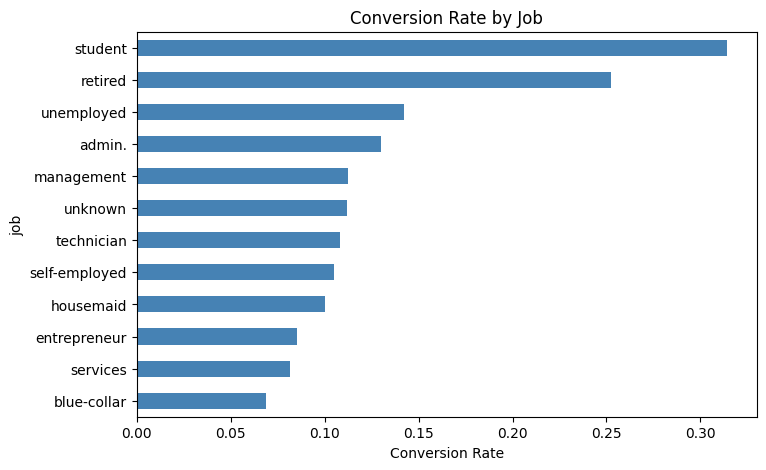

In [6]:
conversion_by_job = df.groupby('job')['y'].apply(lambda x: (x == 'yes').mean()).sort_values()

conversion_by_job.plot(kind='barh', color='steelblue', figsize=(8, 5), title='Conversion Rate by Job')
plt.xlabel('Conversion Rate')
plt.show()

**Key insight:** Students (31%) and retired (25%) convert 3–4x better than blue-collar workers (7%).  
Likely reason: students have no major financial commitments; retired clients have savings to invest.

## 5. Segmentation by Age Group

We use `pd.cut()` to bin continuous age into groups, then calculate conversion per group.

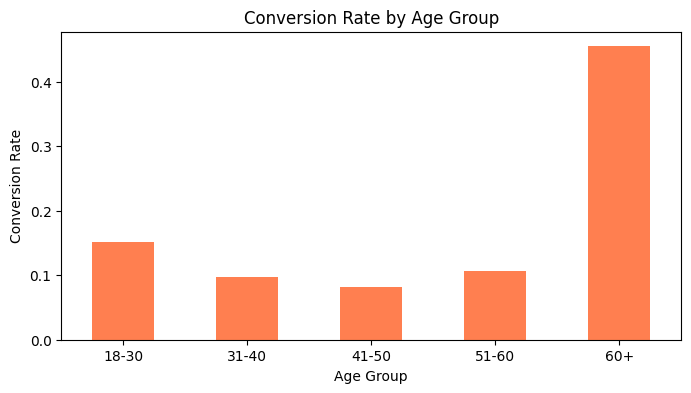

In [7]:
df['age_group'] = pd.cut(df['age'], bins=[18, 30, 40, 50, 60, 100], labels=['18-30', '31-40', '41-50', '51-60', '60+'])

conversion_by_age = df.groupby('age_group', observed=True)['y'].apply(lambda x: (x == 'yes').mean())

conversion_by_age.plot(kind='bar', color='coral', figsize=(8, 4), title='Conversion Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Conversion Rate')
plt.xticks(rotation=0)
plt.show()

**Key insight:** U-shaped curve — youngest (18–30) and oldest (60+) convert best.  
The 60+ group shows 46% conversion — 5x higher than the 41–50 group (9%), who face peak financial pressure (mortgages, children, loans).

## 6. A/B Test: Does Call Duration Affect Outcome?

**Hypotheses:**
- H₀: No significant difference in call duration between subscribers and non-subscribers
- H₁: Subscribers have significantly longer calls

**Significance level:** α = 0.05

In [ ]:
yes_duration = df[df['y'] == 'yes']['duration']
no_duration  = df[df['y'] == 'no']['duration']

t_stat, p_value = stats.ttest_ind(yes_duration, no_duration)
print(f"Yes avg duration: {yes_duration.mean():.0f} sec")
print(f"No avg duration:  {no_duration.mean():.0f} sec")
print(f"p-value: {p_value:.6f}")

Yes avg duration: 553 sec
No avg duration:  221 sec
p-value: 0.000000


**Result:** p-value ≈ 0 → reject H₀. Subscribers talk 2.5x longer (553 vs 221 sec).

⚠️ **Important:** This is correlation, not causation.  
Longer calls are a *consequence* of client interest — not the cause of subscription.  
`duration` should **not** be used as a predictor in a real model, since call length is only known after the call ends.

## 7. Seasonality vs Targeting: Calls & Conversion by Month

High conversion in some months might reflect targeting strategy rather than true seasonality.  
We compare conversion rate AND number of calls side by side.

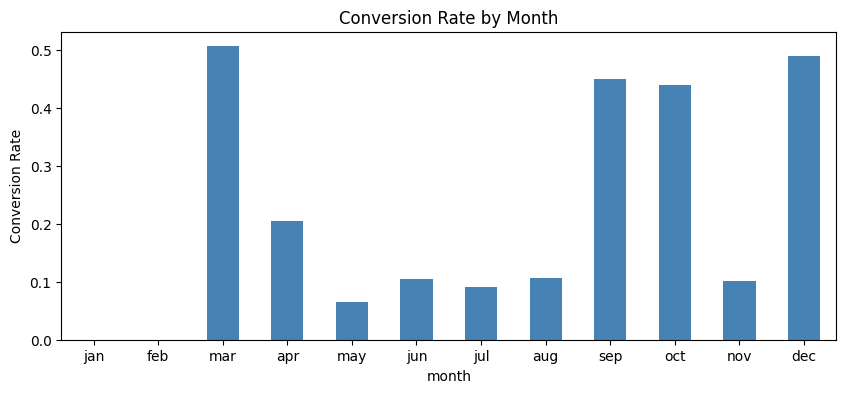

In [8]:
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']

conversion_by_month = df.groupby('month')['y'].apply(lambda x: (x == 'yes').mean()).reindex(month_order)

conversion_by_month.plot(kind='bar', color='steelblue', figsize=(10, 4), title='Conversion Rate by Month')
plt.xticks(rotation=0)
plt.ylabel('Conversion Rate')
plt.show()

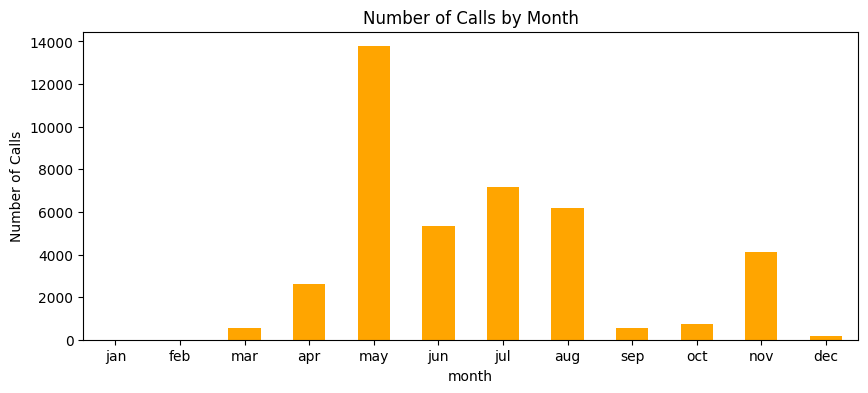

In [9]:
calls_by_month = df.groupby('month')['y'].count().reindex(month_order)

calls_by_month.plot(kind='bar', color='orange', figsize=(10, 4), title='Number of Calls by Month')
plt.xticks(rotation=0)
plt.ylabel('Number of Calls')
plt.show()

**Key insight — Selection Bias:**

| Month | Calls | Conversion |
|-------|-------|------------|
| May | ~14,000 | 7% |
| March | ~500 | 51% |
| December | ~200 | 49% |

March and December show high conversion because the bank called **very few, carefully selected clients**.  
May shows low conversion because it was a **mass campaign** with no targeting.  

⚠️ High conversion in a small sample ≠ best month. It's a sign of better targeting.

## 8. Business Conclusion

**Dataset:** Bank Marketing Campaign · 41,188 clients · Portugal (UCI ML Repository)

**Goal:** Identify which client segments are most likely to subscribe to a term deposit.

**Key Findings:**

1. **Overall conversion: 11.3%** — only 1 in 9 clients subscribes (class imbalance)
2. **Best segments by job:** Students (31%) and retired (25%) — 3–4x higher than blue-collar (7%)
3. **Best segments by age:** 60+ (46%) — 5x higher than 41–50 (9%)
4. **Call duration:** Subscribers talk 2.5x longer (553 vs 221 sec), p-value ≈ 0 — statistically significant. ⚠️ Correlation, not causation — duration cannot be used as a predictor.
5. **Best months:** March, September, October, December (44–51%) vs May (7%) — driven by targeting strategy, not seasonality (selection bias confirmed by call volume data).

**Recommendation:**  
Focus campaign budget on **retired clients aged 60+** contacted in **autumn/winter months**.  
Avoid mass calling in May — high volume, low return.  
Use job and age as primary targeting criteria for future campaigns.